# WFP Food Prices in Nigeria

## 1. Setup & Extract

In [1]:
# import libraries

import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# import dataset

df = pd.read_csv('wfp_food_prices_nga.csv')

## 2. Data Quality Checks (QA)

In [3]:
df.head()

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,15/01/2002,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,cereals and tubers,Maize,51,KG,actual,Wholesale,NGN,175.92,1.54
1,15/01/2002,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,cereals and tubers,Millet,73,KG,actual,Wholesale,NGN,150.18,1.31
2,15/01/2002,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,cereals and tubers,Rice (imported),64,KG,actual,Wholesale,NGN,358.70,3.14
3,15/01/2002,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,cereals and tubers,Sorghum,65,KG,actual,Wholesale,NGN,155.61,1.36
4,15/01/2002,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,pulses and nuts,Beans (niebe),120,KG,actual,Wholesale,NGN,196.87,1.72


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 87963 entries, 0 to 87962
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          87963 non-null  str    
 1   admin1        87963 non-null  str    
 2   admin2        87963 non-null  str    
 3   market        87963 non-null  str    
 4   market_id     87963 non-null  int64  
 5   latitude      87963 non-null  float64
 6   longitude     87963 non-null  float64
 7   category      87963 non-null  str    
 8   commodity     87963 non-null  str    
 9   commodity_id  87963 non-null  int64  
 10  unit          87963 non-null  str    
 11  priceflag     87963 non-null  str    
 12  pricetype     87963 non-null  str    
 13  currency      87963 non-null  str    
 14  price         87963 non-null  float64
 15  usdprice      87963 non-null  float64
dtypes: float64(4), int64(2), str(10)
memory usage: 10.7 MB


In [5]:
df.describe()

,market_id,latitude,longitude,commodity_id,price,usdprice
count,87963.000000,87963.000000,87963.000000,87963.000000,87963.000000,87963.000000
mean,2465.478940,11.553796,10.826987,197.095290,5107.080016,14.637577
std,1188.156604,1.493669,2.811267,169.502048,10120.288800,29.718454
min,1037.000000,5.150000,3.400000,51.000000,1.000000,0.002300
25%,1976.000000,11.290000,9.580000,73.000000,270.000000,0.710000
50%,2386.000000,11.830000,11.730000,119.000000,906.670000,1.760000
75%,2396.000000,12.490000,13.150000,254.000000,4000.000000,4.115000
max,10943.000000,13.640000,14.490000,1043.000000,138000.000000,453.170000


In [6]:
df.shape

(87963, 16)

In [7]:
df.sample(5)

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
48472,15/02/2022,Yobe,Yunusari,Yunusari,2392,13.15,11.54,"meat, fish and eggs",Fish,139,KG,actual,Retail,NGN,313.00,0.75
34947,15/11/2019,Jigawa,Kaugama,Gujungu,1973,12.36,9.58,non-food,Fuel (petrol-gasoline),285,L,actual,Retail,NGN,144.20,0.47
25203,15/10/2018,Gombe,Akko,Gombe,1972,10.28,11.17,cereals and tubers,Bread,55,Unit,actual,Retail,NGN,306.49,1.01
77686,15/01/2025,Borno,Konduga,Konduga,3173,11.66,13.42,vegetables and fruits,Spinach,404,300 G,aggregate,Retail,NGN,77.08,0.05
12213,15/02/2017,Yobe,Geidam,Geidam,2393,12.89,11.92,vegetables and fruits,Onions,173,0.5 KG,actual,Retail,NGN,63.00,0.21


In [8]:
# backup

df_raw = df.copy()

In [9]:
# duplicate check

df.duplicated().sum()

np.int64(0)

In [10]:
df['currency'].unique()

<StringArray>
['NGN']
Length: 1, dtype: str

In [11]:
df['unit'].unique()

<StringArray>
[        'KG',     '100 KG',      '50 KG',       'Unit',     '2.6 KG',
     '2.8 KG',     '2.7 KG',          'L',     '2.5 KG',      '100 L',
     '2.1 KG',      '400 G',     '2.2 KG',     '0.5 KG',     '30 pcs',
     '1.3 KG',      '300 G',      '250 G',      '500 G', '100 Tubers']
Length: 20, dtype: str

In [12]:
df['priceflag'].unique()

<StringArray>
['actual', 'actual,aggregate', 'aggregate']
Length: 3, dtype: str

In [13]:
df[df['priceflag'] == 'actual,aggregate'].head(3)

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
51789,15/05/2019,Borno,Biu,Biu,1968,10.61,12.19,cereals and tubers,Bread,55,Unit,"actual,aggregate",Retail,NGN,162.0,0.53
51790,15/05/2019,Borno,Biu,Biu,1968,10.61,12.19,cereals and tubers,"Cassava meal (gari, yellow)",482,100 KG,"actual,aggregate",Wholesale,NGN,9940.0,32.49
51791,15/05/2019,Borno,Biu,Biu,1968,10.61,12.19,cereals and tubers,Gari (white),483,100 KG,"actual,aggregate",Wholesale,NGN,9852.0,32.20


In [14]:
df['pricetype'].unique()

<StringArray>
['Wholesale', 'Retail']
Length: 2, dtype: str

In [15]:
df.groupby('commodity')['unit'].unique()

commodity
Bananas                                            [1.3 KG]
Beans (niebe)                                          [KG]
Beans (red)                                        [2.5 KG]
Beans (white)                                      [2.5 KG]
Bread                                                [Unit]
Cassava meal (gari, yellow)                    [KG, 100 KG]
Cowpeas                                            [2.5 KG]
Cowpeas (brown)                                [KG, 100 KG]
Cowpeas (white)                                [KG, 100 KG]
Eggs                                               [30 pcs]
Fish                                                   [KG]
Fuel (diesel)                                           [L]
Fuel (petrol-gasoline)                                  [L]
Gari (white)                                   [KG, 100 KG]
Groundnuts                                         [2.2 KG]
Groundnuts (shelled)                           [100 KG, KG]
Maize                         

In [16]:
df[df['priceflag'] == 'actual,aggregate']['admin1'].value_counts()

admin1
Yobe       447
Borno      420
Kebbi       51
Kaduna      50
Gombe       49
Katsina     48
Jigawa      45
Oyo         37
Adamawa     17
Lagos       17
Kano        16
Zamfara     16
Name: count, dtype: int64

In [17]:
df[df['priceflag'] != 'actual']['admin1'].value_counts()

admin1
Borno      14574
Yobe        9586
Kaduna      1811
Adamawa     1770
Kebbi       1040
Gombe       1029
Oyo         1017
Zamfara      984
Katsina      956
Lagos        953
Kano         949
Jigawa       875
Abia         630
Name: count, dtype: int64

In [18]:
# keeping only verified actual prices

df_actual = df[df['priceflag'] == 'actual']
df_actual.sample(5)

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
17189,15/10/2017,Yobe,Borsari,Bursari,2401,12.50,11.50,miscellaneous food,Salt,185,250 G,actual,Retail,NGN,400.0,1.31
37648,15/02/2020,Yobe,Gulani,Gulani (Tettaba),2400,10.81,11.73,"meat, fish and eggs",Meat (goat),451,KG,actual,Retail,NGN,1000.0,3.27
35664,15/12/2019,Kaduna,Giwa,Giwa,1971,11.28,7.42,cereals and tubers,Maize (yellow),136,100 KG,actual,Wholesale,NGN,9375.0,30.65
8306,15/06/2016,Adamawa,Hong,Mubi,1980,10.27,13.26,cereals and tubers,Rice (local),71,100 KG,actual,Wholesale,NGN,27400.0,138.10
45926,15/10/2021,Yobe,Yusufari,Yusufari,2389,13.06,11.17,pulses and nuts,Beans (red),78,2.5 KG,actual,Retail,NGN,1390.0,3.39


## 3. Transform - Cleaning & Filtering

In [19]:
# splitting df by pricetype
df_retail = df_actual[df_actual['pricetype'] == 'Retail'].copy()
df_wholesale = df_actual[df_actual['pricetype'] == 'Wholesale'].copy()

# quick sanity check
print(df.shape)
print(df_actual.shape)
print(df_retail.shape, df_wholesale.shape)

(87963, 16)
(51789, 16)
(36811, 16) (14978, 16)


In [20]:
df_retail['date'] = pd.to_datetime(df_retail['date'], dayfirst=True, errors='coerce')
df_retail['date'].isnull().sum()

np.int64(0)

In [21]:
# number of markets per state and their value counts
df_retail.groupby('admin1')['admin2'].value_counts()

admin1   admin2      
Abia     Oboma Ngwa       279
Adamawa  Hong             357
Borno    Maiduguri       8803
         Konduga         5067
         Biu              391
Gombe    Akko             377
Jigawa   Kaugama          436
Kaduna   Lere             428
         Giwa             318
Kano     Dawakin Tofa     365
Katsina  Dandume          392
         Mai'Adua           3
Kebbi    Gwandu           400
Lagos    Kosofe           347
Oyo      Ibadan North     431
Sokoto   Gada               3
Yobe     Damaturu        1944
         Potiskum        1766
         Karasuwa        1686
         Nguru           1660
         Geidam          1634
         Yunusari        1611
         Jakusko         1608
         Borsari         1603
         Yusufari        1582
         Gujba           1477
         Gulani          1451
Zamfara  Kaura Namoda     392
Name: count, dtype: int64

## 4. Transform - Unit Normalization
##### Unit map dictionary
This is a manual mapping since there were only 20 known values, no regex needed.

In [22]:
unit_map = {
    'KG': (1, 'KG'), '100 KG': (100, 'KG'), '50 KG': (50, 'KG'),
    '2.6 KG': (2.6, 'KG'), '2.8 KG': (2.8, 'KG'), '2.7 KG': (2.7, 'KG'),
    '2.5 KG': (2.5, 'KG'), '2.1 KG': (2.1, 'KG'), '2.2 KG': (2.2, 'KG'),
    '0.5 KG': (0.5, 'KG'), '1.3 KG': (1.3, 'KG'),
    '400 G': (400, 'G'), '300 G': (300, 'G'), '250 G': (250, 'G'), '500 G': (500, 'G'),
    'L': (1, 'L'), '100 L': (100, 'L'),
    'Unit': (1, 'Unit'), '30 pcs': (30, 'pcs'), '100 Tubers': (100, 'Tubers'),
}

df_retail['quantity'] = df_retail['unit'].map(lambda u: unit_map[u][0])
df_retail['base_unit'] = df_retail['unit'].map(lambda u: unit_map[u][1])

In [23]:
df_retail.sample(3)

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice,quantity,base_unit
40172,2020-09-15,Borno,Maiduguri,Tashan Bama,2398,11.81,13.18,pulses and nuts,Cowpeas,218,2.5 KG,actual,Retail,NGN,481.0,1.26,2.5,KG
24762,2018-09-15,Yobe,Gulani,Gulani (Tettaba),2400,10.81,11.73,"meat, fish and eggs",Meat (goat),451,KG,actual,Retail,NGN,1300.0,4.26,1.0,KG
42052,2021-01-15,Yobe,Damaturu,Damaturu (Sunday Market),2391,11.74,11.96,vegetables and fruits,Onions,173,0.5 KG,actual,Retail,NGN,63.0,0.17,0.5,KG


In [24]:
# renaming some column names for easy identification

df_retail = df_retail.rename(columns={'admin1':'state', 'admin2':'lga'})
df_wholesale = df_wholesale.rename(columns={'admin1':'state', 'admin2':'lga'})

In [25]:
# dropping some columns

df_retail = df_retail.drop(['market_id', 'commodity_id', 'priceflag', 'pricetype', 'currency'], axis=1)
df_wholesale = df_wholesale.drop(['market_id', 'commodity_id', 'priceflag', 'pricetype', 'currency'], axis=1)

In [26]:
df_retail.sample(5)

,date,state,lga,market,latitude,longitude,category,commodity,unit,price,usdprice,quantity,base_unit
38079,2020-04-15,Borno,Konduga,Abba Gamaram,11.86,13.15,"meat, fish and eggs",Fish,KG,533.0,1.48,1.0,KG
30871,2019-05-15,Yobe,Potiskum,Potiskum,11.71,11.08,"meat, fish and eggs",Fish,KG,75.0,0.25,1.0,KG
14201,2017-05-15,Yobe,Yunusari,Yunusari,13.15,11.54,pulses and nuts,Cowpeas,2.5 KG,495.0,1.62,2.5,KG
18729,2017-12-15,Yobe,Karasuwa,Bade (Gashua),12.87,11.04,vegetables and fruits,Bananas,1.3 KG,110.0,0.35,1.3,KG
13458,2017-04-15,Yobe,Jakusko,Jakusko,12.20,10.88,pulses and nuts,Beans (white),2.5 KG,729.0,2.39,2.5,KG


In [27]:
df_retail.groupby('commodity')['base_unit'].unique()

commodity
Bananas                          [KG]
Beans (red)                      [KG]
Beans (white)                    [KG]
Bread                          [Unit]
Cassava meal (gari, yellow)      [KG]
Cowpeas                          [KG]
Cowpeas (brown)                  [KG]
Cowpeas (white)                  [KG]
Eggs                            [pcs]
Fish                             [KG]
Fuel (diesel)                     [L]
Fuel (petrol-gasoline)            [L]
Gari (white)                     [KG]
Groundnuts                       [KG]
Groundnuts (shelled)             [KG]
Maize (white)                    [KG]
Maize (yellow)                   [KG]
Maize flour                      [KG]
Meat (beef)                      [KG]
Meat (goat)                      [KG]
Milk (powder)                     [G]
Millet                           [KG]
Oil (palm)                        [L]
Oil (vegetable)                   [L]
Onions                           [KG]
Oranges                           [G]
Ri

In [28]:
df_retail['price_per_unit'] = df_retail['price'] / df_retail['quantity']

In [29]:
df_retail.sample(5)

,date,state,lga,market,latitude,longitude,category,commodity,unit,price,usdprice,quantity,base_unit,price_per_unit
38632,2020-05-15,Yobe,Nguru,Nguru,12.87,10.45,"meat, fish and eggs",Eggs,30 pcs,950.0,2.64,30.0,pcs,31.666667
11555,2017-01-15,Borno,Maiduguri,Tashan Bama,11.81,13.18,"meat, fish and eggs",Meat (goat),KG,1350.0,4.44,1.0,KG,1350.000000
18253,2017-12-15,Borno,Konduga,Bullunkutu,11.83,13.09,cereals and tubers,Sorghum,2.7 KG,338.0,1.07,2.7,KG,125.185185
26364,2018-11-15,Yobe,Yusufari,Yusufari,13.06,11.17,oil and fats,Oil (vegetable),L,400.0,1.31,1.0,L,400.000000
18291,2017-12-15,Borno,Maiduguri,Budum,11.85,13.16,vegetables and fruits,Bananas,1.3 KG,225.0,0.72,1.3,KG,173.076923


## 5. Table 1: Commodity Price Trends

In [30]:


commodity_trend = df_retail.groupby(['date', 'commodity'])['price_per_unit'].mean().reset_index()
commodity_trend.columns = ['date', 'commodity', 'avg_price']
commodity_trend.head()

,date,commodity,avg_price
0,2014-05-15,Bread,150.00
1,2014-05-15,"Cassava meal (gari, yellow)",180.18
2,2014-05-15,Cowpeas (brown),169.00
3,2014-05-15,Cowpeas (white),119.72
4,2014-05-15,Fuel (diesel),155.00


#### Commodity trend charts


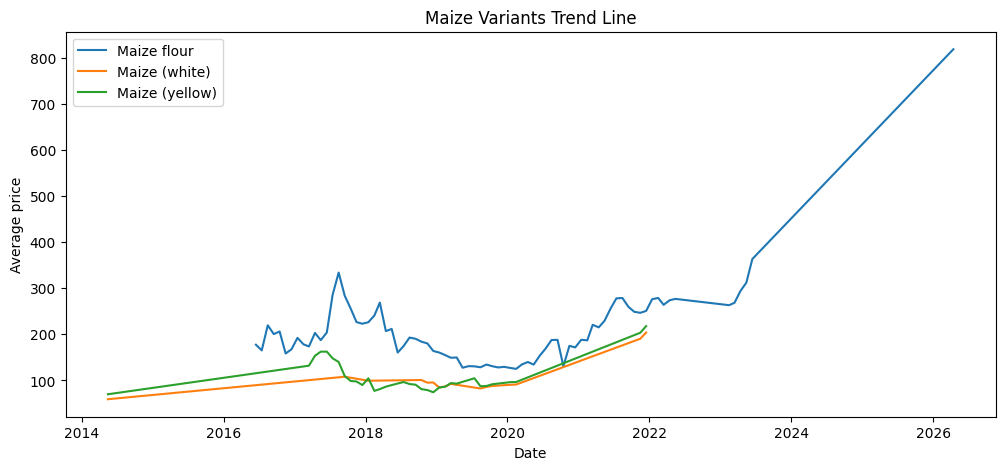

In [31]:
# a. Maize variants comparison

maize_flour = commodity_trend[commodity_trend['commodity'] == 'Maize flour']
maize_white = commodity_trend[commodity_trend['commodity'] == 'Maize (white)']
maize_yellow = commodity_trend[commodity_trend['commodity'] == 'Maize (yellow)']

plt.figure(figsize=(12,5))
plt.plot(maize_flour['date'], maize_flour['avg_price'], label='Maize flour')
plt.plot(maize_white['date'], maize_white['avg_price'], label='Maize (white)')
plt.plot(maize_yellow['date'], maize_yellow['avg_price'], label='Maize (yellow)')
plt.title('Maize Variants Trend Line')
plt.xlabel('Date')
plt.ylabel('Average price')
plt.legend()
plt.show()

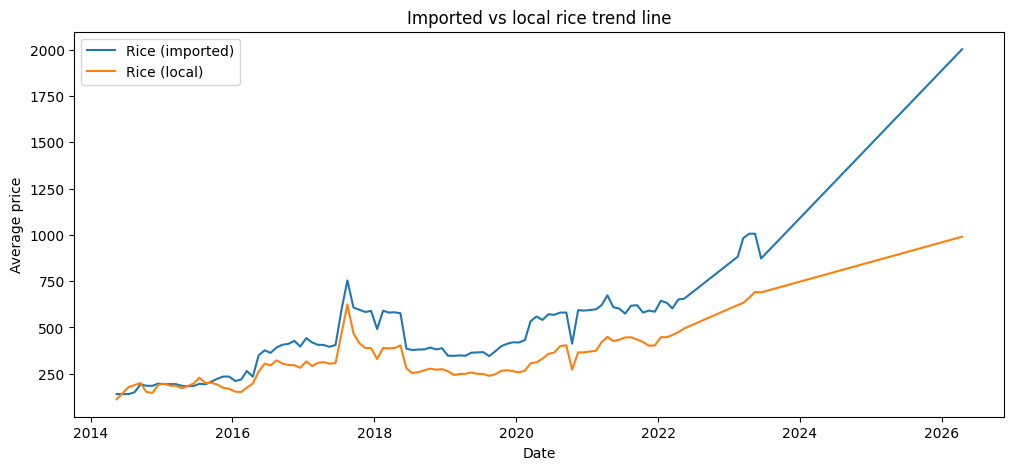

In [32]:
# b. Rice variants comparison

rice_imported = commodity_trend[commodity_trend['commodity'] == 'Rice (imported)']
rice_local = commodity_trend[commodity_trend['commodity'] == 'Rice (local)']

#fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 4))
plt.figure(figsize=(12,5))
plt.plot(rice_imported['date'], rice_imported['avg_price'], label='Rice (imported)')
plt.plot(rice_local['date'], rice_local['avg_price'], label='Rice (local)')
plt.title('Imported vs local rice trend line')
plt.xlabel('Date')
plt.ylabel('Average price')
plt.legend()
plt.show()

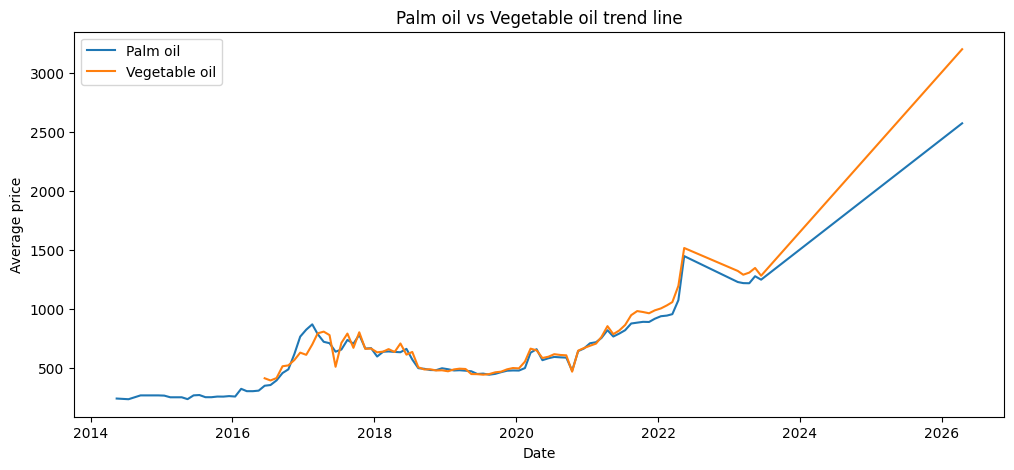

In [33]:
# c. Oil variants comparison

oil_palm = commodity_trend[commodity_trend['commodity'] == 'Oil (palm)']
oil_veg = commodity_trend[commodity_trend['commodity'] == 'Oil (vegetable)']

plt.figure(figsize=(12,5))
plt.plot(oil_palm['date'], oil_palm['avg_price'], label='Palm oil')
plt.plot(oil_veg['date'], oil_veg['avg_price'], label='Vegetable oil')
plt.title('Palm oil vs Vegetable oil trend line')
plt.xlabel('Date')
plt.ylabel('Average price')
plt.legend()
plt.show()

## 6. Table 2: Regional Price Summary

In [34]:


regional_summary = df_retail.groupby(['state', 'commodity'])['price_per_unit'].agg(['mean', 'std']).reset_index()
regional_summary.columns = ['state', 'commodity', 'avg_price', 'price_volatility']
regional_summary.head()


,state,commodity,avg_price,price_volatility
0,Abia,Bread,205.116286,50.436581
1,Abia,"Cassava meal (gari, yellow)",381.985000,0.219203
2,Abia,Cowpeas (brown),922.670000,3.351686
3,Abia,Cowpeas (white),791.795000,51.399592
4,Abia,Fuel (diesel),179.964474,38.256946


In [35]:
palm_oil_by_state = regional_summary[regional_summary['commodity'] == 'Oil (palm)'].sort_values('avg_price', ascending=False)
palm_oil_by_state

,state,commodity,avg_price,price_volatility
56,Borno,Oil (palm),691.067280,305.149654
232,Yobe,Oil (palm),684.955635,280.625740
134,Kano,Oil (palm),567.318947,186.327314
185,Lagos,Oil (palm),559.834500,62.572265
28,Adamawa,Oil (palm),534.024231,94.705011
168,Kebbi,Oil (palm),512.785769,128.563133
117,Kaduna,Oil (palm),494.041224,184.696677
83,Gombe,Oil (palm),492.093810,151.064127
202,Oyo,Oil (palm),478.257568,185.251966
11,Abia,Oil (palm),457.715556,350.816235


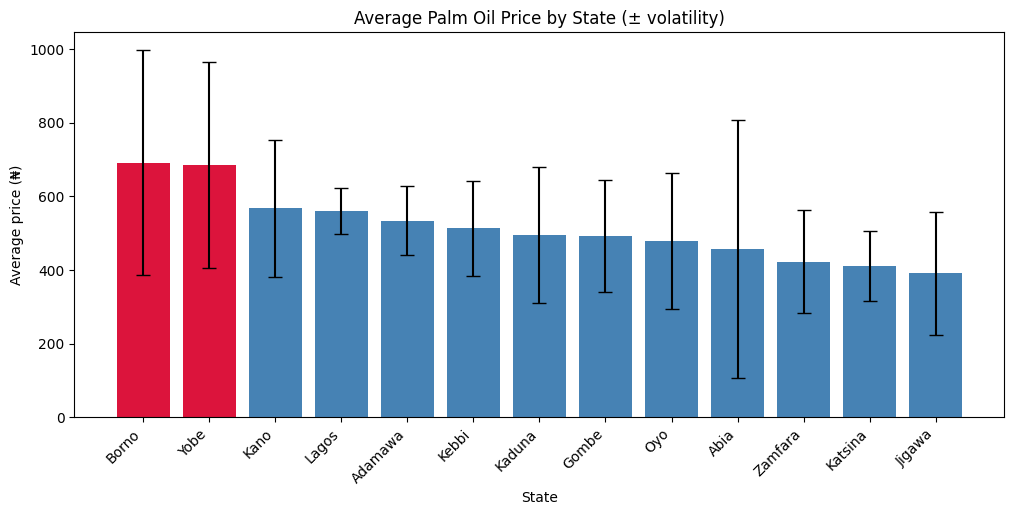

In [36]:
# regional bar chart - palm oil
# showing price volatility per state

colors = ['crimson' if state in ['Borno', 'Yobe'] else 'steelblue' for state in palm_oil_by_state['state']]

plt.figure(figsize=(12,5))
plt.bar(palm_oil_by_state['state'], palm_oil_by_state['avg_price'],
        yerr=palm_oil_by_state['price_volatility'], capsize=5, color=colors)
plt.title('Average Palm Oil Price by State (± volatility)')
plt.xlabel('State')
plt.ylabel('Average price (₦)')
plt.xticks(rotation=45, ha='right')
plt.show()

#### Period/region setup

In [37]:
# tagging each row as pre- or post-insurgency era, based on the July 2009 split date - for the Retail dataset

df_retail['period'] = np.where(df_retail['date'] < '2009-07-01', 'Pre-insurgency', 'Insurgency-era')

In [38]:
df_retail.head(2)

,date,state,lga,market,latitude,longitude,category,commodity,unit,price,usdprice,quantity,base_unit,price_per_unit,period
2587,2014-05-15,Oyo,Ibadan North,Ibadan,7.4,3.92,cereals and tubers,Bread,Unit,150.00,0.92,1.0,Unit,150.00,Insurgency-era
2588,2014-05-15,Oyo,Ibadan North,Ibadan,7.4,3.92,cereals and tubers,"Cassava meal (gari, yellow)",KG,180.18,1.11,1.0,KG,180.18,Insurgency-era


In [39]:
df_retail.tail(2)

,date,state,lga,market,latitude,longitude,category,commodity,unit,price,usdprice,quantity,base_unit,price_per_unit,period
51787,2026-04-15,Yobe,Karasuwa,Bade (Gashua),12.87,11.04,vegetables and fruits,Tomatoes,0.5 KG,200.0,0.15,0.5,KG,400.000000,Insurgency-era
51788,2026-04-15,Yobe,Karasuwa,Bade (Gashua),12.87,11.04,vegetables and fruits,Watermelons,2.1 KG,1000.0,0.74,2.1,KG,476.190476,Insurgency-era


In [40]:
df_wholesale.head(2)

,date,state,lga,market,latitude,longitude,category,commodity,unit,price,usdprice
0,15/01/2002,Katsina,Jibia,Jibia (CBM),13.08,7.24,cereals and tubers,Maize,KG,175.92,1.54
1,15/01/2002,Katsina,Jibia,Jibia (CBM),13.08,7.24,cereals and tubers,Millet,KG,150.18,1.31


In [41]:
df_wholesale.tail(2)

,date,state,lga,market,latitude,longitude,category,commodity,unit,price,usdprice
47681,15/12/2021,Zamfara,Kaura Namoda,Kaura Namoda,12.6,6.59,pulses and nuts,Cowpeas (white),100 KG,38548.0,94.08
47683,15/12/2021,Zamfara,Kaura Namoda,Kaura Namoda,12.6,6.59,pulses and nuts,Groundnuts (shelled),100 KG,50836.0,124.07


In [42]:
print(df_retail['date'].min(), df_retail['date'].max())
print(df_wholesale['date'].min(), df_wholesale['date'].max())

2014-05-15 00:00:00 2026-04-15 00:00:00
15/01/2002 15/12/2021


Retail data only starts in `2014` - after the insurgency was already underway - so Wholesale data `(2002-2021)` is used for the pre/post comparison instead.

In [43]:
df_wholesale['date'] = pd.to_datetime(df_wholesale['date'], dayfirst=True, errors='coerce')

In [44]:
# tagging each row as pre- or post-insurgency era, based on the July 2009 split date - for the Wholesale dataset

df_wholesale['period'] = np.where(df_wholesale['date'] < '2009-07-01', 'Pre-insurgency', 'Insurgency-era')


In [45]:
df_wholesale.sample(3)

,date,state,lga,market,latitude,longitude,category,commodity,unit,price,usdprice,period
35568,2019-12-15,Borno,Maiduguri,Maiduguri,11.83,13.15,cereals and tubers,Gari (white),100 KG,8125.00,26.56,Insurgency-era
1710,2012-03-15,Kano,Dawakin Tofa,Dawanau,12.09,8.43,cereals and tubers,Maize (white),100 KG,6200.00,39.35,Insurgency-era
1578,2011-09-15,Katsina,Jibia,Jibia (CBM),13.08,7.24,cereals and tubers,Maize,KG,151.82,0.97,Insurgency-era


In [46]:
df_wholesale['quantity'] = df_wholesale['unit'].map(lambda u: unit_map[u][0])
df_wholesale['base_unit'] = df_wholesale['unit'].map(lambda u: unit_map[u][1])
df_wholesale['price_per_unit'] = df_wholesale['price'] / df_wholesale['quantity']

In [47]:
# build the region group

df_wholesale['region_group'] = np.where(df_wholesale['state'].isin(['Borno', 'Yobe']), 'Borno/Yobe', 'Rest of Nigeria')


## 7. Table 3: Pre/Post-Insurgency Comparison

In [48]:
# comparison table

insurgency_comparison = df_wholesale.groupby(['region_group', 'period', 'commodity'])['price_per_unit'].mean().reset_index()

In [49]:
insurgency_comparison

,region_group,period,commodity,price_per_unit
0,Borno/Yobe,Insurgency-era,"Cassava meal (gari, yellow)",153.979504
1,Borno/Yobe,Insurgency-era,Cowpeas (brown),225.781964
2,Borno/Yobe,Insurgency-era,Cowpeas (white),197.782042
3,Borno/Yobe,Insurgency-era,Gari (white),143.563442
4,Borno/Yobe,Insurgency-era,Groundnuts (shelled),217.250660
5,Borno/Yobe,Insurgency-era,Maize,174.197812
6,Borno/Yobe,Insurgency-era,Maize (white),94.909501
7,Borno/Yobe,Insurgency-era,Maize (yellow),105.493844
8,Borno/Yobe,Insurgency-era,Millet,120.368010
9,Borno/Yobe,Insurgency-era,Oil (palm),3341.360765


In [50]:
# check to show commodities that exist in both periods
insurgency_comparison.groupby('period')['commodity'].value_counts()


period          commodity                  
Insurgency-era  Cassava meal (gari, yellow)    2
                Yam                            2
                Sorghum (white)                2
                Sorghum (brown)                2
                Sorghum                        2
                Rice (local)                   2
                Rice (imported)                2
                Oil (palm)                     2
                Rice (milled, local)           2
                Maize (yellow)                 2
                Maize (white)                  2
                Maize                          2
                Groundnuts (shelled)           2
                Gari (white)                   2
                Cowpeas (white)                2
                Cowpeas (brown)                2
                Millet                         2
                Yam (Abuja)                    1
Pre-insurgency  Maize                          2
                Millet   

In [51]:
# insurgency comparison charts
# using maize
maize_insurgency = insurgency_comparison[insurgency_comparison['commodity'] == 'Maize']
maize_insurgency

,region_group,period,commodity,price_per_unit
5,Borno/Yobe,Insurgency-era,Maize,174.197812
17,Borno/Yobe,Pre-insurgency,Maize,178.851818
27,Rest of Nigeria,Insurgency-era,Maize,179.834513
41,Rest of Nigeria,Pre-insurgency,Maize,153.771849


In [52]:
# reshape using .pivot

maize_pivot = maize_insurgency.pivot(index='region_group', columns='period', values='price_per_unit')
maize_pivot = maize_pivot[['Pre-insurgency', 'Insurgency-era']]
maize_pivot

period,Pre-insurgency,Insurgency-era
region_group,,
Borno/Yobe,178.851818,174.197812
Rest of Nigeria,153.771849,179.834513


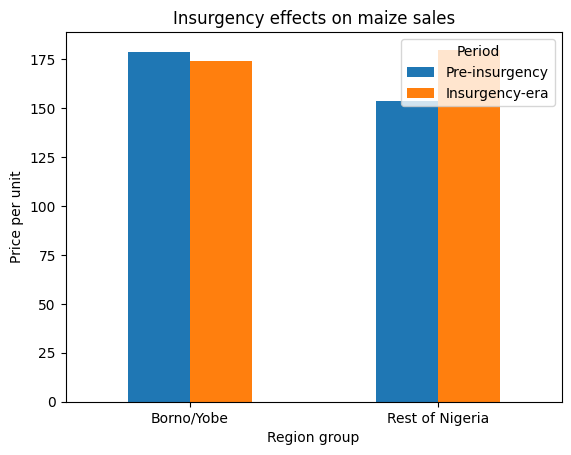

In [53]:
maize_pivot.plot(kind='bar')
plt.title('Insurgency effects on maize sales')
plt.xlabel('Region group')
plt.ylabel('Price per unit')
plt.xticks(rotation=0)
plt.legend(title='Period')
plt.show()

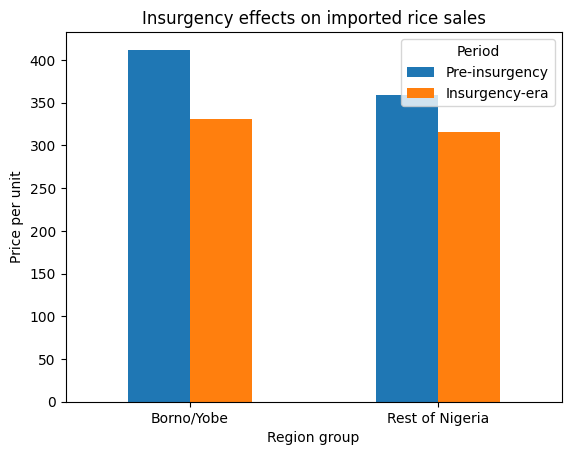

In [54]:
# using imported rice
imp_rice_insurgency = insurgency_comparison[insurgency_comparison['commodity'] == 'Rice (imported)']

# reshape using .pivot
imp_rice_pivot = imp_rice_insurgency.pivot(index='region_group', columns='period', values='price_per_unit')
imp_rice_pivot = imp_rice_pivot[['Pre-insurgency', 'Insurgency-era']]

# plotting
imp_rice_pivot.plot(kind='bar')
plt.title('Insurgency effects on imported rice sales')
plt.xlabel('Region group')
plt.ylabel('Price per unit')
plt.xticks(rotation=0)
plt.legend(title='Period')
plt.show()

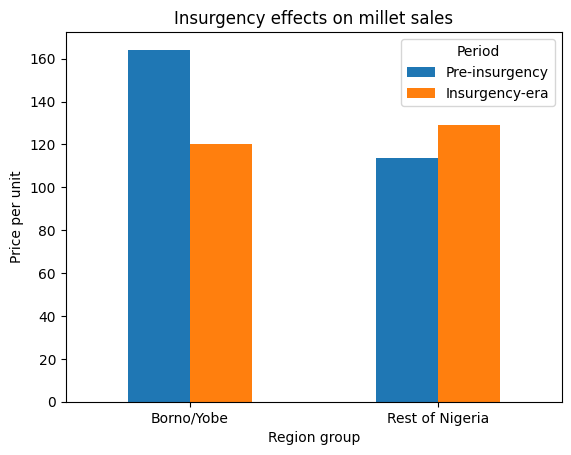

In [55]:
# using millet
millet_insurgency = insurgency_comparison[insurgency_comparison['commodity'] == 'Millet']

# reshape using .pivot
millet_pivot = millet_insurgency.pivot(index='region_group', columns='period', values='price_per_unit')
millet_pivot = millet_pivot[['Pre-insurgency', 'Insurgency-era']]

# plotting
millet_pivot.plot(kind='bar')
plt.title('Insurgency effects on millet sales')
plt.xlabel('Region group')
plt.ylabel('Price per unit')
plt.xticks(rotation=0)
plt.legend(title='Period')
plt.show()

## 8. Load - Saving to SQLite

In [56]:
# sqlite phase  - adding tables to a database
# adding the commodity_trend table

wfp_conn = sqlite3.connect('food_prices.db') # opening a connection
commodity_trend.to_sql('commodity_trend', wfp_conn, if_exists='replace', index=False) # writing a table into it
wfp_conn.close() # closing the connection

In [57]:
wfp_conn = sqlite3.connect('food_prices.db')
check = pd.read_sql('SELECT * FROM commodity_trend LIMIT 5', wfp_conn)
wfp_conn.close()
check

,date,commodity,avg_price
0,2014-05-15 00:00:00,Bread,150.00
1,2014-05-15 00:00:00,"Cassava meal (gari, yellow)",180.18
2,2014-05-15 00:00:00,Cowpeas (brown),169.00
3,2014-05-15 00:00:00,Cowpeas (white),119.72
4,2014-05-15 00:00:00,Fuel (diesel),155.00


In [58]:
# adding the regional_summary table
wfp_conn = sqlite3.connect('food_prices.db') # opening a connection
regional_summary.to_sql('regional_summary', wfp_conn, if_exists='replace', index=False) # writing a table into it
wfp_conn.close() # closing the connection

# adding that of insurgency_comparison
wfp_conn = sqlite3.connect('food_prices.db')
insurgency_comparison.to_sql('insurgency_comparison', wfp_conn, if_exists='replace', index=False)
wfp_conn.close()

# adding df_retail
wfp_conn = sqlite3.connect('food_prices.db')
df_retail.to_sql('df_retail', wfp_conn, if_exists='replace', index=False)
wfp_conn.close()

# adding df_wholesale
wfp_conn = sqlite3.connect('food_prices.db')
df_wholesale.to_sql('df_wholesale', wfp_conn, if_exists='replace', index=False)
wfp_conn.close()

In [59]:


wfp_conn = sqlite3.connect("food_prices.db")

# Query the SQLite master table for all table names
query = "SELECT name FROM sqlite_master WHERE type='table';"
check = pd.read_sql(query, wfp_conn)

wfp_conn.close()
check


,name
0,commodity_trend
1,regional_summary
2,insurgency_comparison
3,df_retail
4,df_wholesale


## 9. Reusable ETL Pipeline

This section repackages that same logic into callable functions (`extract()`, `transform()`, `build_tables()`, `load()`), so the whole pipeline can be re-run end-to-end in four lines instead of manually re-running every cell in order. It's wrapped for reusability.

In [60]:
def extract(filepath):
    """Load the raw WFP food prices CSV."""
    df = pd.read_csv(filepath)
    return df


def clean_split(df_actual, pricetype):
    """Shared cleaning steps applied to both the Retail and Wholesale slices:
    date conversion, renaming, dropping now-redundant columns, unit
    normalization, and pre/post-insurgency tagging."""
    d = df_actual[df_actual['pricetype'] == pricetype].copy()
    d['date'] = pd.to_datetime(d['date'], dayfirst=True, errors='coerce')
    d = d.rename(columns={'admin1': 'state', 'admin2': 'lga'})
    d = d.drop(['market_id', 'commodity_id', 'priceflag', 'pricetype', 'currency'], axis=1)
    d['quantity'] = d['unit'].map(lambda u: unit_map[u][0])
    d['base_unit'] = d['unit'].map(lambda u: unit_map[u][1])
    d['price_per_unit'] = d['price'] / d['quantity']
    d['period'] = np.where(d['date'] < '2009-07-01', 'Pre-insurgency', 'Insurgency-era')
    return d


def transform(df):
    """Filter to verified ('actual') prices, split by pricetype, and clean both slices."""
    df_actual = df[df['priceflag'] == 'actual']
    df_retail = clean_split(df_actual, 'Retail')
    df_wholesale = clean_split(df_actual, 'Wholesale')
    df_wholesale['region_group'] = np.where(
        df_wholesale['state'].isin(['Borno', 'Yobe']), 'Borno/Yobe', 'Rest of Nigeria'
    )
    return df_retail, df_wholesale


def build_tables(df_retail, df_wholesale):
    """Build the three analysis tables: commodity trend, regional summary, insurgency comparison."""
    commodity_trend = df_retail.groupby(['date', 'commodity'])['price_per_unit'].mean().reset_index()
    commodity_trend.columns = ['date', 'commodity', 'avg_price']

    regional_summary = df_retail.groupby(['state', 'commodity'])['price_per_unit'].agg(['mean', 'std']).reset_index()
    regional_summary.columns = ['state', 'commodity', 'avg_price', 'price_volatility']

    insurgency_comparison = df_wholesale.groupby(['region_group', 'period', 'commodity'])['price_per_unit'].mean().reset_index()

    return commodity_trend, regional_summary, insurgency_comparison


def load(df_retail, df_wholesale, commodity_trend, regional_summary, insurgency_comparison, db_path='food_prices.db'):
    """Save the cleaned datasets and all three analysis tables to SQLite."""
    conn = sqlite3.connect(db_path)
    commodity_trend.to_sql('commodity_trend', conn, if_exists='replace', index=False)
    regional_summary.to_sql('regional_summary', conn, if_exists='replace', index=False)
    insurgency_comparison.to_sql('insurgency_comparison', conn, if_exists='replace', index=False)
    df_retail.to_sql('df_retail', conn, if_exists='replace', index=False)
    df_wholesale.to_sql('df_wholesale', conn, if_exists='replace', index=False)
    conn.close()
    print(f"Loaded 5 tables into {db_path}")

### Running the full pipeline end-to-end

Calling all four functions in sequence - this is what makes it a real, repeatable *pipeline* rather than a notebook of loose cells.

In [61]:
raw_df = extract('wfp_food_prices_nga.csv')
df_retail_final, df_wholesale_final = transform(raw_df)
commodity_trend_final, regional_summary_final, insurgency_comparison_final = build_tables(df_retail_final, df_wholesale_final)
load(df_retail_final, df_wholesale_final, commodity_trend_final, regional_summary_final, insurgency_comparison_final)

Loaded 5 tables into food_prices.db


### Verifying the pipeline output matches the exploratory work above

In [62]:
conn = sqlite3.connect('food_prices.db')
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
check = pd.read_sql('SELECT * FROM regional_summary WHERE commodity = "Oil (palm)" ORDER BY avg_price DESC LIMIT 3', conn)
conn.close()
print(tables)
check

                    name
0        commodity_trend
1       regional_summary
2  insurgency_comparison
3              df_retail
4           df_wholesale


,state,commodity,avg_price,price_volatility
0,Borno,Oil (palm),691.067280,305.149654
1,Yobe,Oil (palm),684.955635,280.625740
2,Kano,Oil (palm),567.318947,186.327314


## 10. Key Insights

- **Scope of analysis:** 51,789 verified ("actual") price records were used out of 87,963 raw rows — 36,174 rows were excluded for being aggregated/estimated rather than directly observed. Of those excluded rows, Borno (14,574) and Yobe (9,586) accounted for the large majority, reflecting real data-collection challenges in Nigeria's conflict-affected northeast.
  `df[df['priceflag'] != 'actual']['admin1'].value_counts()`

- **Retail vs Wholesale coverage:** Retail price data spans 2014–2026 (36,811 records); Wholesale spans 2002–2021 (14,978 records). Because Retail data doesn't reach back before the insurgency began, Wholesale data was used specifically for the pre/post-insurgency comparison.

- **Commodity price trends:** Maize flour rose from `~ $177.55` to `~$818.96` per unit between 2014 and 2026 — a `361%` increase. Imported rice rose even more sharply, from `~$140.36` to `~$2,002.47` over the same period, far outpacing local rice's rise from `~$112.59` to `~$990.24` — imported rice has become proportionally more expensive relative to local rice over time.
  `commodity_trend[commodity_trend['commodity']=='Maize flour']`

- **Regional price differences (Palm Oil):** Borno had the highest average palm oil price (₦691.07), while Jigawa had the lowest (₦390.33). Abia showed the highest price volatility (std ₦350.81) of any state — nearly as large as its own average price, meaning Abia's palm oil price swings dramatically month to month, more than any other state.
  `regional_summary[regional_summary['commodity']=='Oil (palm)'].sort_values('mean', ascending=False)`

- **Pre/post-insurgency comparison (Wholesale data, split at July 2009):** results were mixed across commodities, not uniform. Maize and Millet prices in Borno/Yobe stayed flat or fell (−2.6% and −26.7% respectively) while Rest-of-Nigeria prices rose (+16.9% and +13.5%) — consistent with a hypothesis that local demand weakened while supply was redirected elsewhere. However, imported rice fell in *both* regions (−19.5% Borno/Yobe, −12.1% Rest of Nigeria), suggesting import/exchange-rate factors unrelated to the insurgency were also at play. This should be read as a plausible pattern, not a proven causal effect — Borno/Yobe's pre-insurgency sample is thin (91 records vs. 3,220 in the insurgency era), which limits how much confidence to place in that earlier baseline.